In [1]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter as fsf
from plots.mpltoolkit import mpl_loc, fancy_legend, named_colors, load_style_sheet, negative_log
import numpy as np
import vice
import sys
import os
sys.path.insert(0, "..")
from src.utils import subsample_stars, get_velocity_evolution, get_velocity_profile
load_style_sheet("papers")
print(sys.version_info[:])

/Users/jamesjohnson/Work/Research/lib/public-dev/VICE/vice/version.py:137: VersionWarning: Using an un-released version of VICE.
  if not self.isreleased: warnings.warn("""\


(3, 12, 3, 'final', 0)


In [2]:
output = vice.output("../outputs/expifr-GSE/initial")
extra = np.genfromtxt("%s_analogdata.out" % (output.name))
output.stars["absz"] = [abs(_) for _ in extra[:,-1][:output.stars.size[0]]]

/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_97558/3748942586.py:27: RuntimeWarning: divide by zero encountered in log10
  rh = [np.log10(r / g / solar) for r, g in zip(zone.history["mass(%s)" % (rprocelem)], zone.history["mgas"])]
/var/folders/26/nqb98q9x5_q6brmqy4v21dqm0000gp/T/ipykernel_97558/3748942586.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  rmg = [r - mg for r, mg in zip(rh, mgh)]


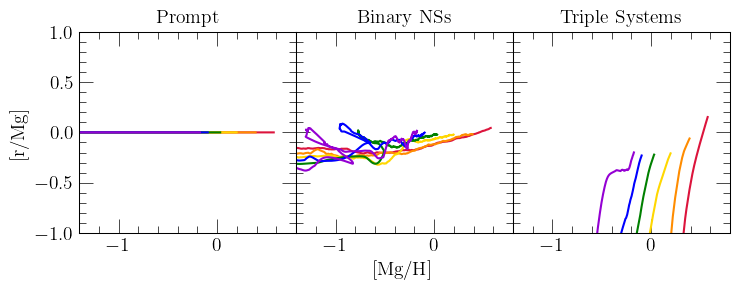

In [17]:
RADII = [3, 5, 7, 9, 11, 13]
COLORS = ["crimson", "darkorange", "gold", "green", "blue", "darkviolet"]

fig = plt.figure(figsize = (7.5, 3))
axes = []
for i in range(3):
    kwargs = {}
    if i:
        kwargs["sharex"] = axes[0]
        kwargs["sharey"] = axes[0]
    else: pass
    axes.append(fig.add_subplot(131 + i, **kwargs))
    if i: plt.setp(axes[i].get_yticklabels(), visible = False)
axes[0].set_xlim([-1.4, 0.8])
axes[0].set_ylim([-1, 1])
axes[1].set_xlabel(r"[Mg/H]")
axes[0].set_ylabel(r"[r/Mg]")
axes[0].set_title("Prompt")
axes[1].set_title("Binary NSs")
axes[2].set_title("Triple Systems")

def plot_evol(ax, output, radius, rprocelem, zone_width = 0.1, **kwargs):
    solar = 1.0e-9
    zone = int(radius / zone_width)
    zone = output.zones["zone%d" % (zone)]
    mgh = zone.history["[o/h]"]
    rh = [np.log10(r / g / solar) for r, g in zip(zone.history["mass(%s)" % (rprocelem)], zone.history["mgas"])]
    rmg = [r - mg for r, mg in zip(rh, mgh)]
    ax.plot(mgh, rmg, **kwargs)

for j, elem in enumerate(["tl", "pb", "bi"]):
    for i in range(len(RADII)):
        kwargs = {
            "c": named_colors()[COLORS[i]],
            "label": r"$%d$ kpc" % (RADII[i])
        }
        plot_evol(axes[j], output, RADII[i], elem, **kwargs)

plt.tight_layout()
plt.subplots_adjust(wspace = 0)
plt.show()